|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Words to tokens to numbers<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: Zipf's law in characters and tokens<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# for getting text data off the web
import requests
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# !pip install tiktoken
import tiktoken

In [2]:
# GPT-4's tokenizer
tokenizer = tiktoken.get_encoding('cl100k_base')

# Exercise 1: Counting occurances in numbers and letters

In [4]:
# a quick intro to np.unique

nums = np.array([ 1,1,3,2,2,2,9,9,9,-1,-1,-1,-1,-1 ])
uniq,counts = np.unique(nums, return_counts=True)

for n,c in zip(uniq,counts):
  print(f'The number {n} appears {c} times.')

The number -1 appears 5 times.
The number 1 appears 2 times.
The number 2 appears 3 times.
The number 3 appears 1 times.
The number 9 appears 3 times.


In [5]:
# also works for strings?
text = 'Hello, my name is Mike and I like to each chocolate.'
np.unique(text) # nope :(

array(['Hello, my name is Mike and I like to each chocolate.'],
      dtype='<U52')

In [7]:
# but this works:
uniq = set(text)
counts = np.zeros(len(uniq))
for i,u in enumerate(uniq):
  counts[i] = text.count(u)

# or using list-comprehension
#counts = [ text.count(u) for u in uniq ]

# print out
for n,c in zip(uniq,counts):
  print(f'The letter "{n}" appears {c} times.')

The letter "H" appears 1.0 times.
The letter "," appears 1.0 times.
The letter "a" appears 4.0 times.
The letter "k" appears 2.0 times.
The letter "h" appears 2.0 times.
The letter "l" appears 4.0 times.
The letter "d" appears 1.0 times.
The letter "." appears 1.0 times.
The letter " " appears 10.0 times.
The letter "i" appears 3.0 times.
The letter "I" appears 1.0 times.
The letter "s" appears 1.0 times.
The letter "e" appears 6.0 times.
The letter "n" appears 2.0 times.
The letter "t" appears 2.0 times.
The letter "y" appears 1.0 times.
The letter "o" appears 4.0 times.
The letter "c" appears 3.0 times.
The letter "m" appears 2.0 times.
The letter "M" appears 1.0 times.


# Exercise 2: Explore Zipf's law in books

In [8]:
# all books have the same url format; they are unique by numerical code
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

KeyboardInterrupt: 

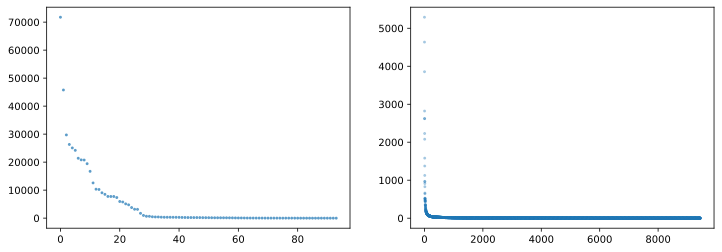

In [9]:
_,axs = plt.subplots(1,2,figsize=(12,4))

for code,title in bookurls:

  # get the text
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text

  # Zipf's law for characters
  counts = [ text.count(u) for u in set(text) ]
  axs[0].plot(np.sort(counts)[::-1],'.',markersize=4,alpha=.6,label=title)

  # and for tokens
  tokens = tokenizer.encode(text)
  unitokens,counts = np.unique(tokens,return_counts=True)
  axs[1].plot(np.sort(counts)[::-1],'.',markersize=4,alpha=.3,label=title)


# axis adjustments
for a in axs:
  a.legend(fontsize=9)
  a.set(xscale='log',yscale='log',xlabel='Sorted index (log)',ylabel='Frequency in text (log)')

axs[0].set_title('Frequency of characters')
axs[1].set_title('Frequency of GPT tokens')

plt.tight_layout()
plt.show()